In [3]:
import zarr
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

path1 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20241114/T2_4uM_mc03_beads_zarr"
path2 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260107"
path3 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/beads_trans_crop_crop"
path4 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260121/exp_crop1"
path5 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp"
path6 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp001"
path7 = "/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002"

RDF1 = zarr.open_array(os.path.join(path1, 'RDF.zarr'), mode = 'r')[:]
RDF2 = zarr.open_array(os.path.join(path2, "RDF.zarr"), mode = 'r')[:]
RDF3 = zarr.open_array(os.path.join(path3, "RDF.zarr"), mode = 'r')[:]
RDF4 = zarr.open_array(os.path.join(path4, "RDF.zarr"), mode = 'r')[:]
RDF5 = zarr.open_array(os.path.join(path5, "RDF.zarr"), mode = 'r')[:]
RDF6 = zarr.open_array(os.path.join(path6, "RDF.zarr"), mode = 'r')[:]
RDF7 = zarr.open_array(os.path.join(path7, "RDF.zarr"), mode = 'r')[:]

RDF=np.concat([RDF1, RDF2, RDF3, RDF4, RDF5, RDF6, RDF7])

RDF3R = zarr.open_array(os.path.join(path3, "RDF_red.zarr"), mode = 'r')[:]
RDF4R = zarr.open_array(os.path.join(path4, "RDF_red.zarr"), mode = 'r')[:]
RDF5R = zarr.open_array(os.path.join(path5, "RDF_red.zarr"), mode = 'r')[:]
RDF6R = zarr.open_array(os.path.join(path6, "RDF_red.zarr"), mode = 'r')[:]
RDF7R = zarr.open_array(os.path.join(path7, "RDF_red.zarr"), mode = 'r')[:]

RDFR=np.concat([RDF3, RDF4, RDF5, RDF6, RDF7])

scale = 0.11
plt.style.use('../libs/my_style.mplstyle')

[Text(0.5, 0, 'r [μm]'), Text(0, 0.5, 'RDF $g(r)$'), (0.0, 2.0)]

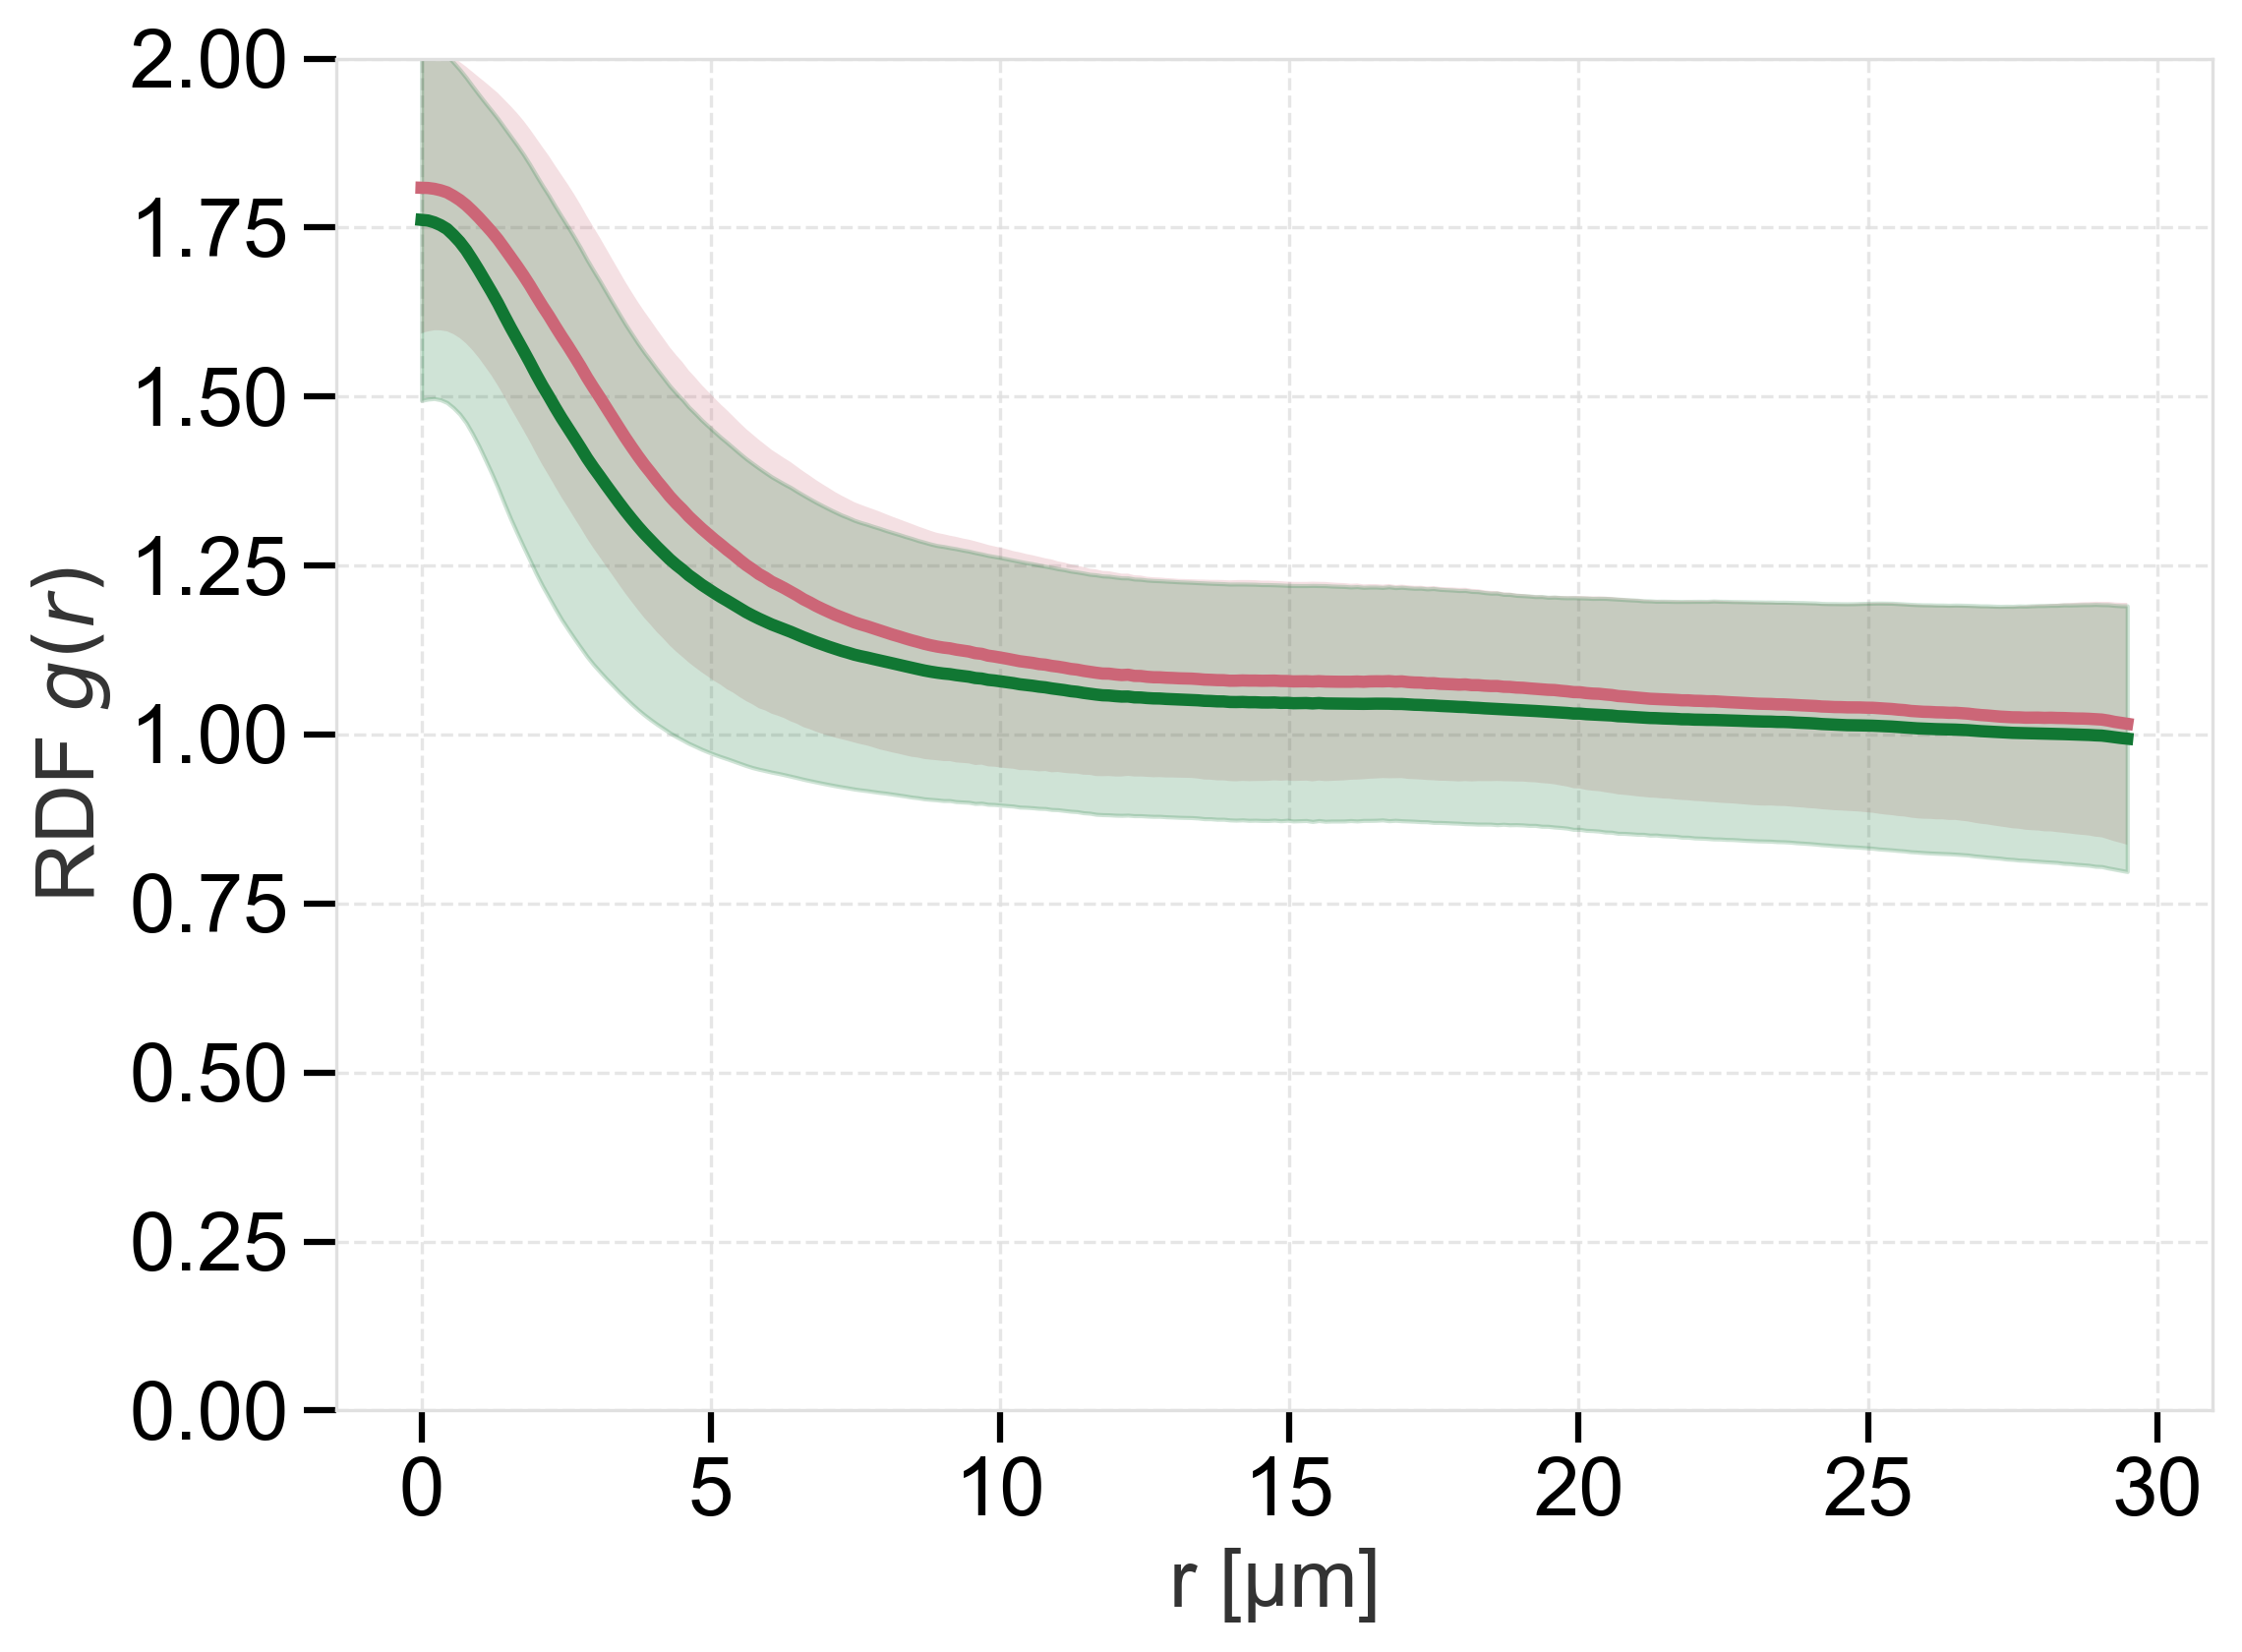

In [5]:
max_radius = RDF.shape[1]
radii_pixels = np.arange(max_radius)

fig, ax = plt.subplots()

"""for i in RDF:
    ax.plot(radii_pixels*scale, i, color="#333333", alpha = 0.005)"""

mean = np.mean(RDF, axis = 0)
std = np.std(RDF, axis = 0)

meanR = np.mean(RDFR, axis = 0)
stdR = np.std(RDFR, axis = 0)

ax.plot(radii_pixels*scale, meanR)
ax.fill_between(radii_pixels*scale, meanR-stdR, meanR+stdR, alpha=0.2)

ax.plot(radii_pixels*scale, mean, color="#117733")
ax.fill_between(radii_pixels*scale, mean-std, mean+std, alpha=0.2, color="#117733")

ax.set(
    xlabel='r [\u03bcm]',
    ylabel='RDF $g(r)$',
    ylim=(0, 2)
)

[Text(0.5, 0, '$\\hat{r}$'),
 Text(0, 0.5, 'RDF $g(\\hat{r})$'),
 (0.0, 10.0),
 (0.75, 2.0)]

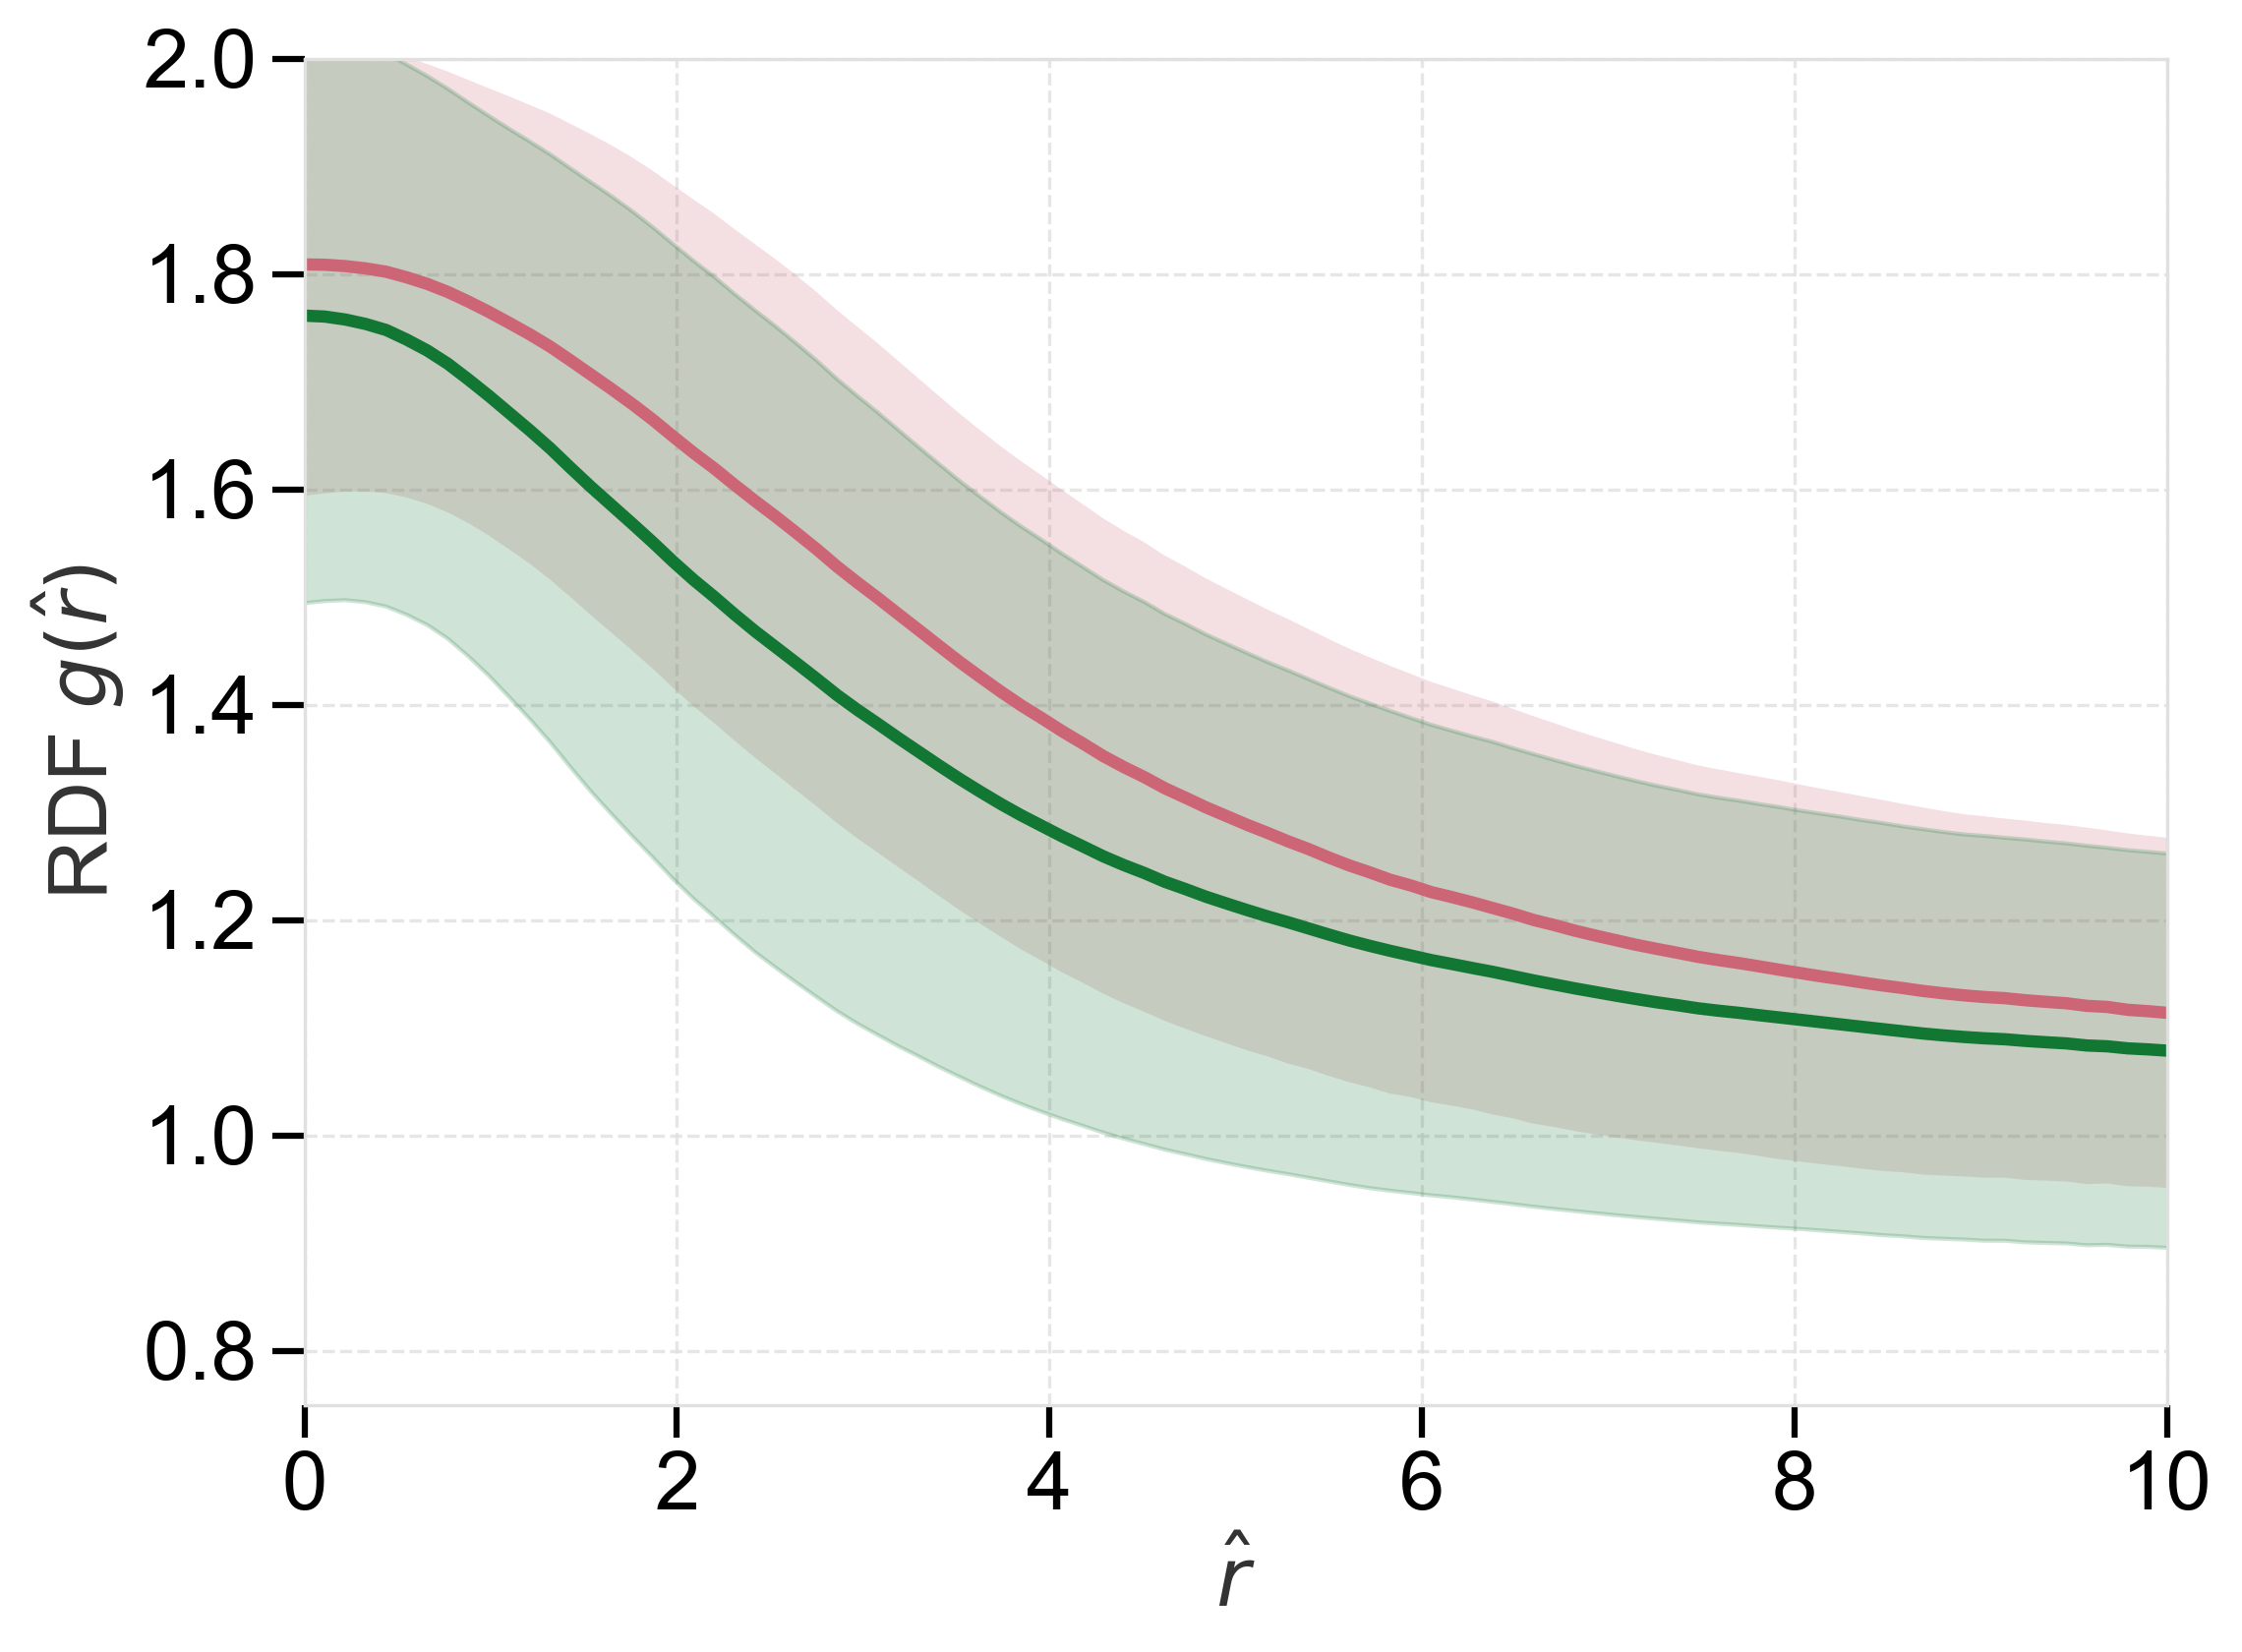

In [7]:
cargo_radius = 0.59

max_radius = RDF.shape[1]
radii_pixels = np.arange(max_radius)

fig, ax = plt.subplots()

"""for i in RDF:
    ax.plot(radii_pixels*scale, i, color="#333333", alpha = 0.005)"""

mean = np.mean(RDF, axis = 0)
std = np.std(RDF, axis = 0)

meanR = np.mean(RDFR, axis = 0)
stdR = np.std(RDFR, axis = 0)

ax.plot(radii_pixels*scale, meanR)
ax.fill_between(radii_pixels*scale, meanR-stdR, meanR+stdR, alpha=0.2)

ax.plot(radii_pixels*scale, mean, color="#117733")
ax.fill_between(radii_pixels*scale, mean-std, mean+std, alpha=0.2, color="#117733")

ax.set(
    xlabel='$\\hat{r}$',
    ylabel='RDF $g(\\hat{r})$',
    xlim=(0,10),
    ylim=(0.75, 2)
)